<a href="https://colab.research.google.com/github/Osho03/UrbanEye/blob/main/retrain_civic_yolov8_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UrbanEye retrain v3 - fix streetlight -> pothole confusion

The old model used **`yolov8n` (nano) + 50 epochs** on an **imbalanced**
dataset (~10k garbage vs ~426 streetlight images), so night streetlights lost.

This notebook trains **`yolov8s` for 150 epochs** on a **balanced** ~9k-image set.

## Before you run
1. Runtime > Change runtime type > **T4 GPU** (free).
2. Get/refresh a FREE Roboflow key: https://app.roboflow.com/settings/api
3. Edit the CONFIG cell and paste your key. Then **Runtime > Run all**.

## What you'll download at the end
- `civic_yolov8.pt`
- `civic_yolov8.onnx`

Keep those downloads - you'll replace the files in
`UrbanEye/backend/ai/models/` with them.

Time: ~3-4 hours on free T4 (150 epochs, ~9k balanced images).


In [ ]:
# ============================================================
# UrbanEye retrain v3: fix streetlight <-> pothole confusion
# Run all cells top to bottom on a FREE T4 GPU.
# ============================================================
!pip install -q -U ultralytics roboflow
import ultralytics
ultralytics.checks()


Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)


In [ ]:
# ================= CONFIG - paste YOUR free Roboflow key =================
# Get/refresh it: https://app.roboflow.com/settings/api
RF_API_KEY = "VHCUCMlRSOEQUhJRUpvz"

# Public Roboflow Universe datasets (same sources as the original civic_v2)
DATASETS = [
    {"tag": "ph", "workspace": "new-workspace-kj87b", "project": "road-damage-detection-iicdh", "version": 1},
    {"tag": "gb", "workspace": "garbage-detection-j813v", "project": "garbage-detection-8hmsd", "version": 1},
    {"tag": "wl", "workspace": "new-workspace-0bgj4", "project": "pipe-leak-yp6il", "version": 1},
    {"tag": "sl", "workspace": "street-lamps", "project": "street-lamps-dpeqc", "version": 1},
    {"tag": "dr", "workspace": "sakib-t1srr", "project": "objection-detection-1yrwu", "version": 1},
    {"tag": "sw", "workspace": "street-cqv2u", "project": "sidewalk-32xvi", "version": 1},
]

# DO NOT change this order - it matches the live backend class names.
UNIFIED_CLASSES = ["garbage", "pothole", "water_leak", "streetlight", "drainage", "sidewalk_damage"]

# ---- v3 improvements (the fix for streetlight->pothole) ----
MODEL = "yolov8s.pt"            # was yolov8n.pt (nano) -> now SMALL, stronger
EPOCHS = 150                    # was 50  -> much more training
IMGSZ = 640
BALANCE_CAP = 1500              # cap each class to ~1500 images (was imbalanced ~10k vs ~426)
BALANCE_FLOOR = 1300            # oversample small classes up to this many

assert not RF_API_KEY.startswith("PASTE"), "Get a free key: https://app.roboflow.com/settings/api"



In [ ]:
# ============ DOWNLOAD FROM ROBOFLOW ============
from roboflow import Roboflow
rf = Roboflow(api_key=RF_API_KEY)
downloaded = []
for spec in DATASETS:
    ds = (rf.workspace(spec["workspace"])
            .project(spec["project"])
            .version(spec["version"])
            .download("yolov8"))
    downloaded.append({"spec": spec, "location": ds.location})
    print(f"[{spec['tag']}] ready at {ds.location}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Road-damage-detection-1 in yolov8:: 100%|██████████| 18510/18510 [00:07<00:00, 2578.44it/s]


[ph] ready at /content/Road-damage-detection-1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Garbage-detection-1 in yolov8:: 100%|██████████| 20940/20940 [00:02<00:00, 8085.06it/s]


[gb] ready at /content/Garbage-detection-1
loading Roboflow workspace...
loading Roboflow project...


...

[sl] ready at /content/street-lamps-1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Objection--detection-1 in yolov8:: 100%|██████████| 28002/28002 [00:07<00:00, 3837.85it/s]


[dr] ready at /content/Objection--detection-1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to SIDEWALK-1 in yolov8:: 100%|██████████| 7085/7085 [00:01<00:00, 4206.22it/s]

[sw] ready at /content/SIDEWALK-1


In [ ]:
# ===== MERGE INTO ONE UNIFIED DATASET (same remap as civic_v2) =====
import glob, os, shutil, yaml, math, random

MERGED = "/content/merged"
IMG_EXTS = (".jpg", ".jpeg", ".png", ".webp")

KEYWORD_TO_UNIFIED = {
    "garb": "garbage", "trash": "garbage", "waste": "garbage", "litter": "garbage",
    "poth": "pothole", "crack": "pothole", "road damage": "pothole",
    "leak": "water_leak", "pipe leak": "water_leak", "water": "water_leak",
    "street-lamp": "streetlight", "street light": "streetlight",
    "lightpost": "streetlight", "asimetrica": "streetlight",
    "drain": "drainage", "sewer": "drainage", "manhole": "drainage", "hole": "drainage",
    "sidewalk": "sidewalk_damage", "edge break": "sidewalk_damage",
    "joint": "sidewalk_damage", "metal grate": "sidewalk_damage", "patch": "sidewalk_damage",
}

def unify_index(raw_name):
    n = str(raw_name).lower()
    for kw, unified in KEYWORD_TO_UNIFIED.items():
        if kw in n:
            return UNIFIED_CLASSES.index(unified)
    return None

def find_image(images_dir, stem):
    for ext in IMG_EXTS:
        p = os.path.join(images_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None

for split in ("train", "valid"):
    os.makedirs(f"{MERGED}/images/{split}", exist_ok=True)
    os.makedirs(f"{MERGED}/labels/{split}", exist_ok=True)

stats = {c: 0 for c in UNIFIED_CLASSES}
skipped_boxes = 0

for entry in downloaded:
    tag = entry["spec"]["tag"]
    root = entry["location"]
    with open(os.path.join(root, "data.yaml")) as f:
        names = yaml.safe_load(f)["names"]
    if isinstance(names, dict):
        names = [names[k] for k in sorted(names)]
    id_map = [unify_index(n) for n in names]
    print(f"[{tag}] source -> unified: {list(zip(names, id_map))}")

    for split in ("train", "valid", "test"):
        out_split = "train" if split == "train" else "valid"
        img_src = os.path.join(root, split, "images")
        lbl_src = os.path.join(root, split, "labels")
        if not os.path.isdir(lbl_src):
            continue
        for lbl_path in glob.glob(os.path.join(lbl_src, "*.txt")):
            stem = os.path.splitext(os.path.basename(lbl_path))[0]
            img_path = find_image(img_src, stem)
            if img_path is None:
                continue
            new_lines, used = [], set()
            for line in open(lbl_path):
                parts = line.split()
                if len(parts) != 5:
                    continue
                mapped = id_map[int(parts[0])]
                if mapped is None:
                    skipped_boxes += 1
                    continue
                new_lines.append(" ".join([str(mapped)] + parts[1:]))
                used.add(mapped)
            if not new_lines:
                continue
            new_stem = f"{tag}_{stem}"
            shutil.copy(img_path, f"{MERGED}/images/{out_split}/{new_stem}{os.path.splitext(img_path)[1]}")
            with open(f"{MERGED}/labels/{out_split}/{new_stem}.txt", "w") as f:
                f.write("\n".join(new_lines) + "\n")
            for c in used:
                stats[UNIFIED_CLASSES[c]] += 1

print("Before balancing (boxes per class):", stats)
print("Skipped unmapped boxes:", skipped_boxes)


[ph] source -> unified: [('D00', None), ('D10', None), ('D20', None), ('D40', None), ('D43', None), ('D44', None), ('D50', None)]
[gb] source -> unified: [('-', None), ('- collaborate with your team on computer vision projects', None), ('GARBAGE CLASSIFICATION 3 - v2 GC1', 0), ('Roboflow is an end-to-end computer vision platform that helps you', None)]
[wl] source -> unified: [('0', None), ('leak', 2)]
[sl] source -> unified: [('Asimetrica abierta', 3), ('Asimetrica cerrada', 3), ('lightpost', 3), ('street-lamp', 3), ('t-b', None), ('t-c', None)]
[dr] source -> unified: [('Drain Hole', 4), ('Pothole', 1), ('Sewer Cover', 4), ('speed-breaker', None)]
[sw] source -> unified: [('Cracking', 1), ('Joint D', 5), ('Metal Grate', 5), ('Patch', 5), ('Scaling', None), ('Spalling', None), ('Tactile Tile', None)]
Before balancing (boxes per class): {'garbage': 2287, 'pothole': 1126, 'water_leak': 1463, 'streetlight': 1103, 'drainage': 0, 'sidewalk_damage': 1315}
Skipped unmapped boxes: 130773


In [ ]:
# ===== BALANCE: cap big classes, oversample tiny ones (esp. streetlight) =====
def label_path_for(img, split):
    stem = os.path.splitext(os.path.basename(img))[0]
    return f"{MERGED}/labels/{split}/{stem}.txt"

random.seed(7)
TRAIN_IMG = f"{MERGED}/images/train"
groups = {c: [] for c in UNIFIED_CLASSES}
multi = []
for img in sorted(glob.glob(TRAIN_IMG + "/*")):
    lbl = label_path_for(img, "train")
    if not os.path.exists(lbl):
        continue
    ids = {int(l.split()[0]) for l in open(lbl) if len(l.split()) == 5}
    present = {UNIFIED_CLASSES[i] for i in ids}
    if len(present) == 1:
        groups[list(present)[0]].append(img)
    else:
        multi.append(img)

# 1) Cap the big classes
for c in UNIFIED_CLASSES:
    random.shuffle(groups[c])
    for img in groups[c][BALANCE_CAP:]:
        os.remove(img)
        lbl = label_path_for(img, "train")
        if os.path.exists(lbl):
            os.remove(lbl)
    groups[c] = groups[c][:BALANCE_CAP]
    print(f"[cap] {c:16s} kept {len(groups[c])}")

# 2) Oversample small classes so streetlight etc. no longer drown
for c in UNIFIED_CLASSES:
    n = len(groups[c])
    if n > 0 and n < BALANCE_FLOOR:
        copies = math.ceil(BALANCE_FLOOR / n) - 1
        for i in range(copies):
            for img in list(groups[c]):
                stem, ext = os.path.splitext(os.path.basename(img))
                new_stem = f"{stem}_bal{i}"
                shutil.copy(img, f"{TRAIN_IMG}/{new_stem}{ext}")
                shutil.copy(label_path_for(img, "train"), label_path_for(f"{TRAIN_IMG}/{new_stem}{ext}", "train"))
        print(f"[up]  {c:16s} oversampled x{copies+1} -> ~{min(n*(copies+1), BALANCE_FLOOR+999)} images")
    elif n == 0 and n < BALANCE_FLOOR: # Added this block for clarity, though it implicitly handles the error
        print(f"[up]  {c:16s} has 0 images; skipping oversampling.")

# 3) Report final train split
import collections
final = collections.Counter()
for img in glob.glob(TRAIN_IMG + "/*"):
    ids = {int(l.split()[0]) for l in open(label_path_for(img, "train")) if len(l.split()) == 5}
    for i in ids:
        final[UNIFIED_CLASSES[i]] += 1
print("Final per-class instance counts:", dict(final))
print("Total train images:", len(glob.glob(TRAIN_IMG + "/*")))


[cap] garbage          kept 1500
[cap] pothole          kept 1500
[cap] water_leak       kept 1395
[cap] streetlight      kept 1500
[cap] drainage         kept 0
[cap] sidewalk_damage  kept 798
[up]  drainage         has 0 images; skipping oversampling.
[up]  sidewalk_damage  oversampled x2 -> ~1596 images
Final per-class instance counts: {'sidewalk_damage': 2113, 'pothole': 2017, 'water_leak': 1395, 'garbage': 1500, 'streetlight': 1500}
Total train images: 8008


In [ ]:
# ============ WRITE data.yaml + SANITY CHECK ============
data_yaml = {
    "path": MERGED,
    "train": "images/train",
    "val": "images/valid",
    "names": {i: c for i, c in enumerate(UNIFIED_CLASSES)},
}
with open(f"{MERGED}/data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

train_n = len(glob.glob(f"{MERGED}/images/train/*"))
val_n = len(glob.glob(f"{MERGED}/images/valid/*"))
print(f"data.yaml written | train={train_n}  valid={val_n}")
assert train_n > 300 and val_n > 50, "Too few images - check previous cells."



data.yaml written | train=8008  valid=805


In [8]:
# ============ TRAIN yolov8s (stronger than nano) ============
from ultralytics import YOLO
model = YOLO(MODEL)   # yolov8s.pt - auto-downloads, COCO-pretrained
model.train(
    data=f"{MERGED}/data.yaml",
    epochs=EPOCHS,       # 150
    imgsz=IMGSZ,         # 640
    batch=16,
    patience=25,
    cos_lr=True,
    seed=7,
    name="civic_v3",
    project="/content/runs",
)
BEST = "/content/runs/civic_v3/weights/best.pt"
print("Best weights:", BEST)
print("If Colab disconnects mid-training, resume with:")
print("YOLO('/content/runs/civic_v3/weights/last.pt').train(resume=True)")


Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/merged/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=civic_v3, nbs=64, nms=False, opset=No

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1297.1±520.9 MB/s, size: 45.2 KB)
val: Scanning /content/merged/labels/valid.cache... 805 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 805/805 225.1Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 311 objects (val=311), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=311 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 3.6it/s 14.0s
                   all        805      13869      0.639      0.546      0.488      0.307
               garbage        684      13681       0.76      0.538      0.493      0.294
    

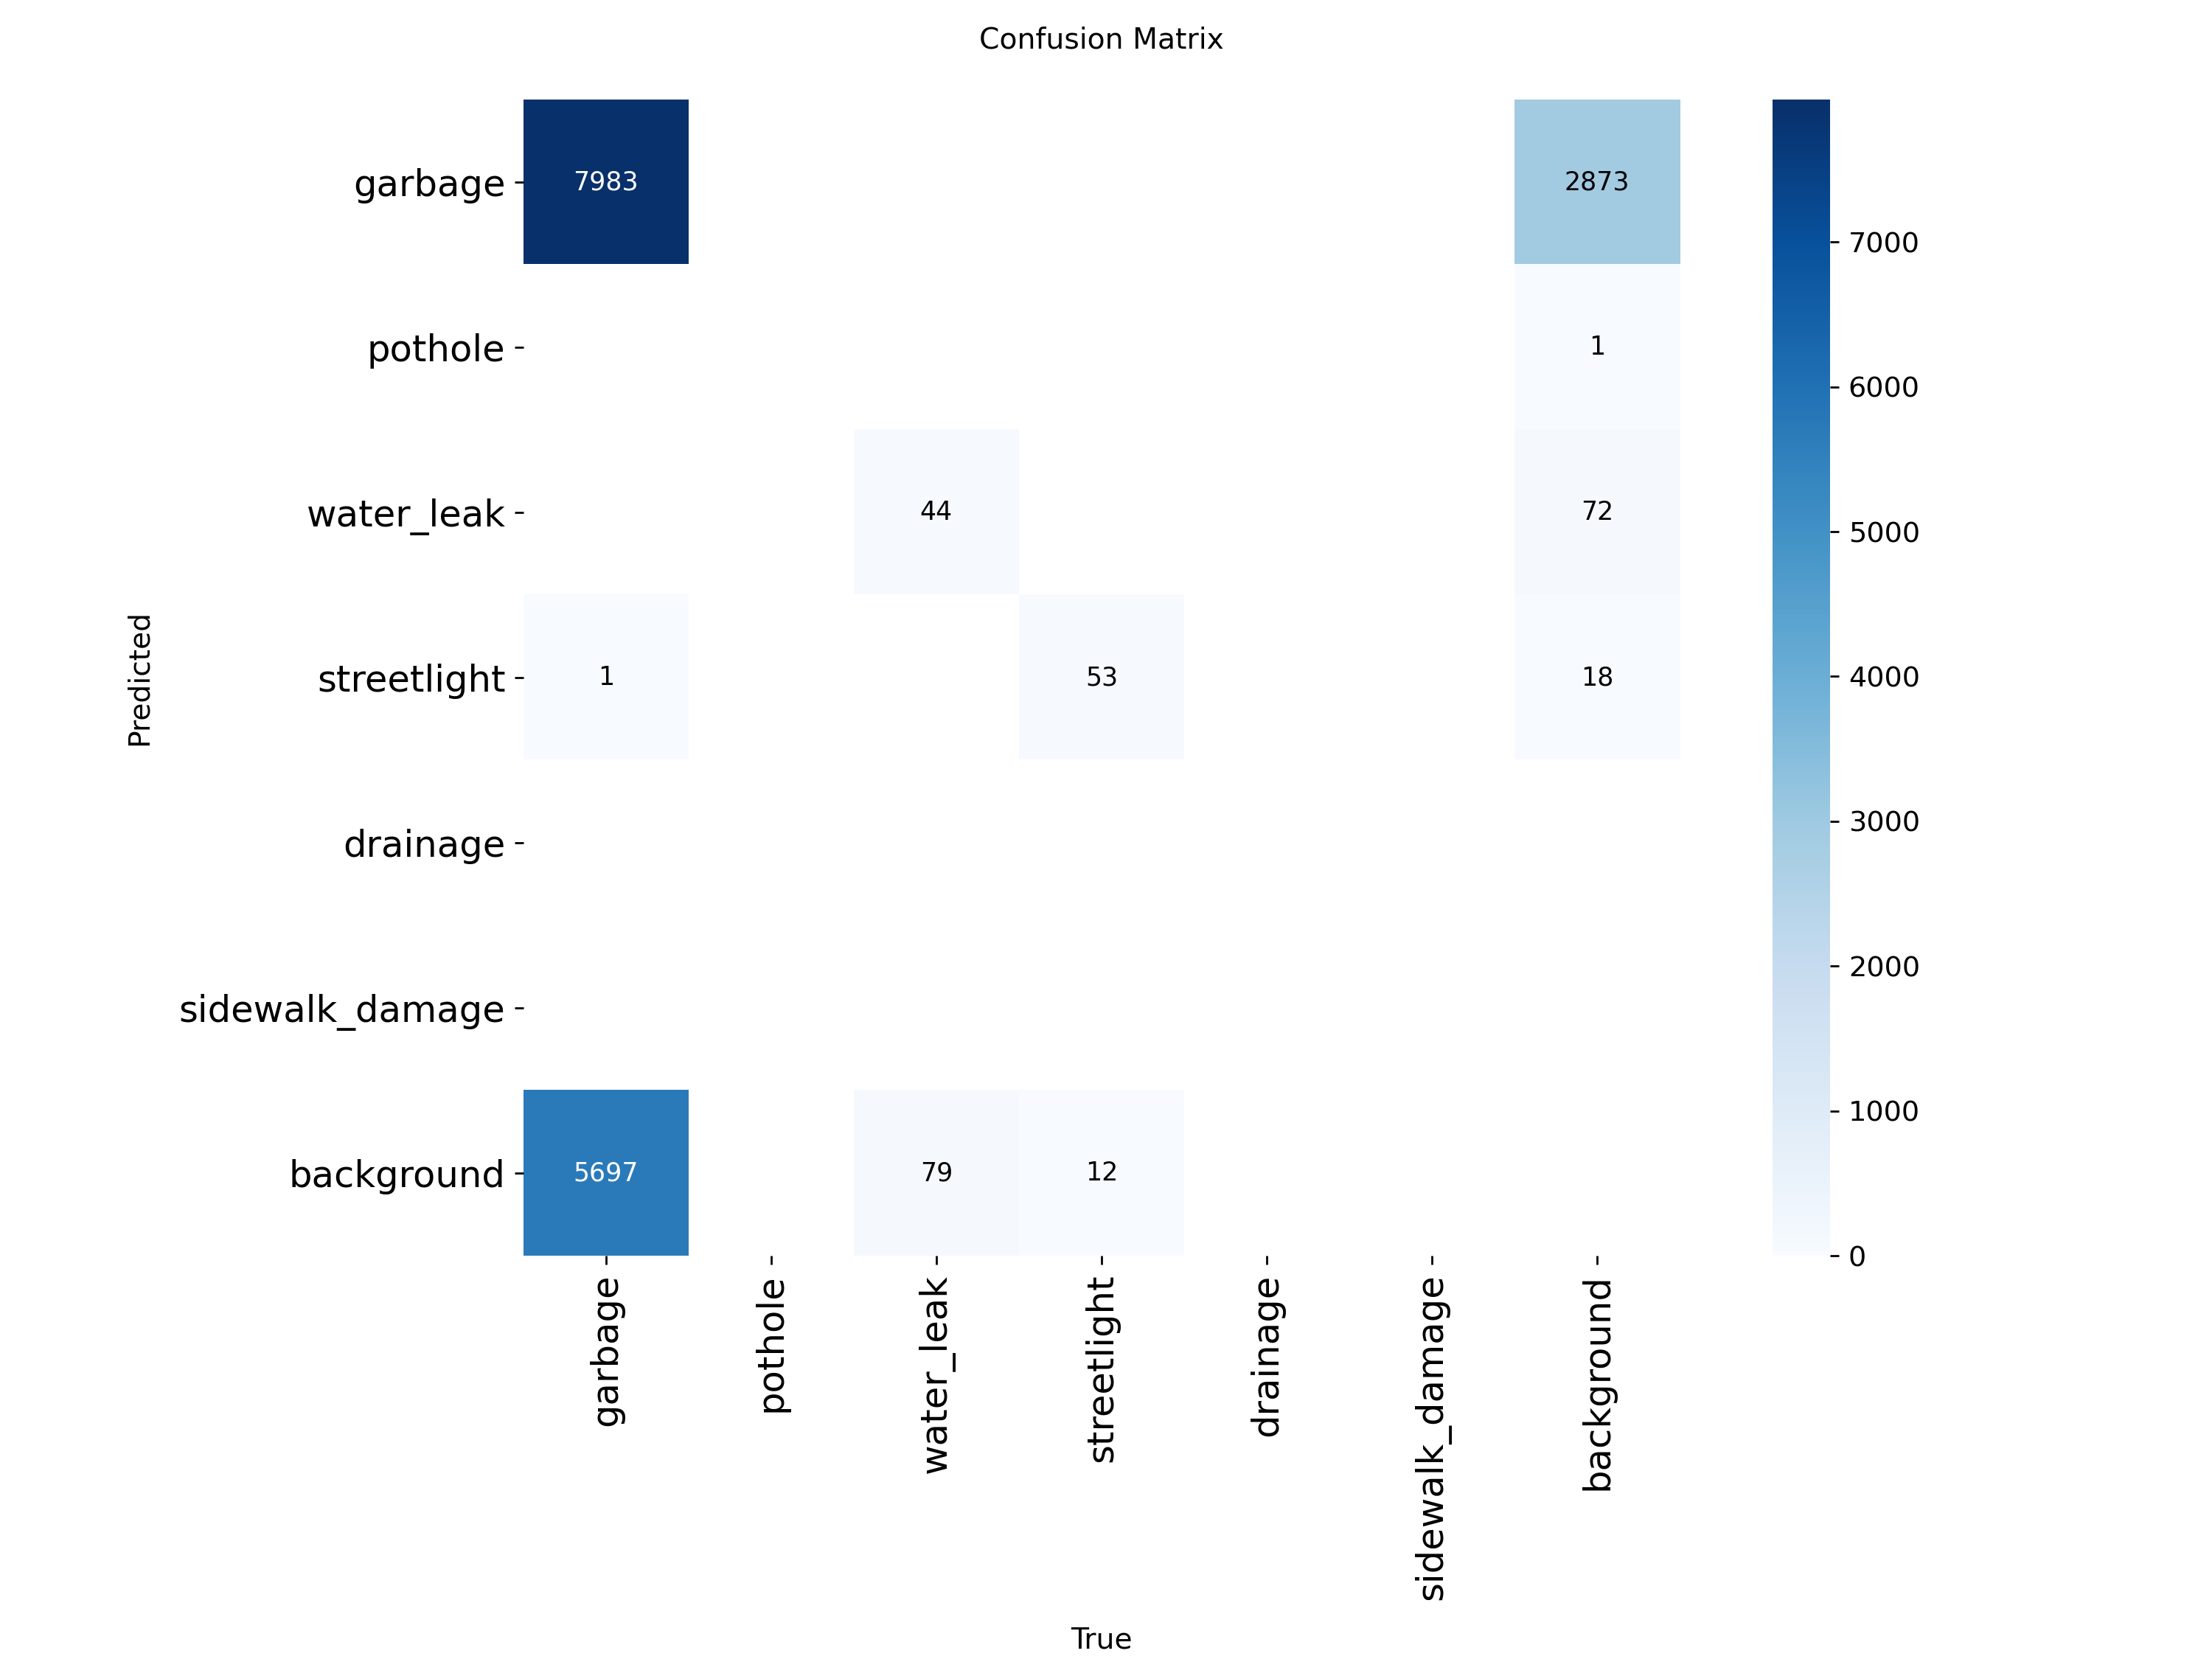

In [9]:
# ============ VALIDATE METRICS (per class!) ============
from ultralytics import YOLO
from IPython.display import Image as IPyImage, display
best = YOLO(BEST)
m = best.val(data=f"{MERGED}/data.yaml", conf=0.30)
print(f"mAP@50    : {m.box.map50:.3f}")
print(f"mAP@50-95 : {m.box.map:.3f}")
n = len(m.box.ap50) if hasattr(m.box, "ap50") else 0
for i in range(n):
    print(f"  {UNIFIED_CLASSES[i]:16s} mAP50={m.box.ap50[i]:.3f}")
cm = sorted(glob.glob("/content/runs/civic_v3/*/confusion_matrix.png") +
            glob.glob("/content/runs/val*/confusion_matrix.png") +
            glob.glob("/content/runs/civic_v3/confusion_matrix.png"))
if cm:
    display(IPyImage(cm[-1], width=520))
else:
    print("confusion_matrix.png not found - check /content/runs/civic_v3/")


In [2]:
# ============ THE KEY TEST: your failing streetlight photo ============
# Upload: the NIGHT streetlight photo that was detected as 'pothole',
# plus a day streetlight, a pure pothole, and a dark road patch.
from google.colab import files
import numpy as np, cv2
from PIL import Image
from IPython.display import display

print("Select your photos now (3-5 files):")
uploaded = files.upload()
for name in uploaded:
    r = best.predict(source=name, conf=0.30, verbose=False)[0]
    dets = []
    for b in r.boxes:
        dets.append((best.names[int(b.cls[0])], round(float(b.conf[0]), 2)))
    dets = sorted(dets, key=lambda t: -t[1])
    print(f"{name} -> {dets if dets else 'NO DETECTION'}")
    if len(r.boxes):
        display(Image.fromarray(r.plot()[:, :, ::-1]))


Select your photos now (3-5 files):


In [3]:
# ============ EXPORT + DOWNLOAD for the backend ============
import shutil
shutil.copy(BEST, "/content/civic_yolov8.pt")           # same name the backend expects
best.export(format="onnx", opset=12, simplify=True)      # creates best.onnx
shutil.copy("/content/runs/civic_v3/weights/best.onnx", "/content/civic_yolov8.onnx")

from google.colab import files
files.download("/content/civic_yolov8.pt")
files.download("/content/civic_yolov8.onnx")
print("Downloaded: civic_yolov8.pt  and  civic_yolov8.onnx")


NameError: name 'BEST' is not defined

In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

CUDA available: False
GPU name: NO GPU


In [5]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## After training - deploy the new brain

1. Extract `civic_yolov8.onnx` from Downloads and copy it to:
   `UrbanEye/backend/ai/models/civic_yolov8.onnx`  (overwrite)
2. Copy `civic_yolov8.pt` to:
   `UrbanEye/backend/ai/models/civic_yolov8.pt`  (overwrite)
3. Commit & push (`cd UrbanEye && git add backend/ai/models && git commit -m "model v3" && git push`).
4. Tell the assistant "model updated" - it will re-verify the live backend
   against the exact photos above.

Optional: with a confident v3 model, the per-class confidence floors in
`backend/ai/yolo_onnx.py` can be relaxed back toward 0.25 so more true
detections come through.
